# Nichtlineare Gleichungssysteme - Newtonverfahren
Gleichungssysteme der Form

$$
    \vec{f}(\vec{x}) = \vec{0}
$$

mit einer Funktion $\vec{f}:\mathbb{R}^n \to \mathbb{R}^n$ können mit dem **Newtonverfahren**
  
* Wähle einen Startwert $\vec{x}$
* Für $k = 1, 2, \ldots$    
    * Löse das LGS $J \vec{\delta} = -\vec{f}(\vec{x})$  
    * Setze $\vec{x} := \vec{x} + \vec{\delta}$

gelöst werden. Wobei 
$$
    J_{ij} = \frac{\partial\, f_i}{\partial x_j} 
$$

die Jacobimatrix von $\vec{f}$ ist, die in jedem Schritt neu berechnet werden muss. Als Abbruchbedingung für das 
Newtonverfahren kann z.B. $|f(\vec{x})|$ (nicht skalierungsinvariant) oder $|\vec{\delta}|$ verwendet werden.

$\vec{f}:\mathbb{R}^n \to \mathbb{R}^n$ bedeutet: es gibt ebensoviele Gleichungen wie Unbekannte. 

## Ein einfaches Beispiel
Wir betrachten das Gleichungssystem

\begin{eqnarray*}
    x + 2 y &=& 3 \\
    4 x + y^2 &=& 5
\end{eqnarray*}

Gesucht sind offenbar um die Schnittpunkte der beiden Kurven

$$
    x = 3 - 2 y \quad \textrm{und} \quad x = \frac{1}{4} \, (5 - y^2)
$$

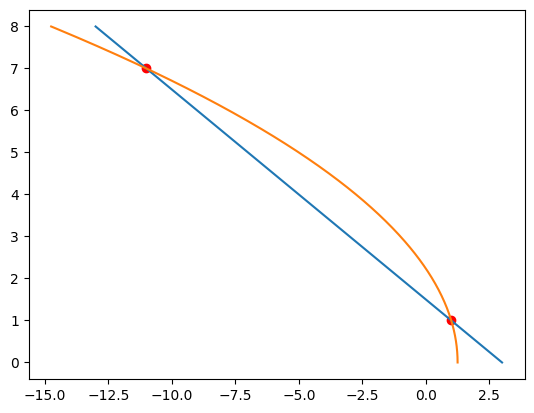

In [53]:
y = np.linspace(0, 8, 500)
plt.plot(3 - 2 * y, y)
plt.plot((5 - y**2) / 4, y)
plt.scatter([1,-11],[1,7], color = "r"); # Lösungen

Wir suchen also die Nullstellen von

$$
    \vec{f}(x, y) = \begin{pmatrix} x + 2 y - 3 \\ 4 x + y^2 - 5 \end{pmatrix}, \qquad
    J = \begin{pmatrix} 1 & 2 \\ 4 & 2 y \end{pmatrix}
$$

Startwert x =  [-5.  5.]
0 . delta =  [-10.   4.]  x =  [-15.   9.]
1 . delta =  [ 3.2 -1.6]  x =  [-11.8   7.4]
2 . delta =  [ 0.75294118 -0.37647059]  x =  [-11.04705882   7.02352941]


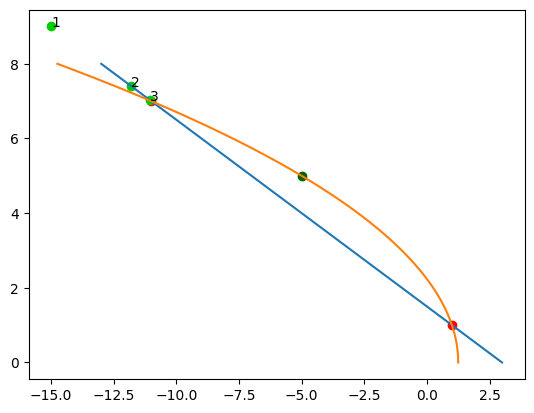

In [54]:
# nochmal der plot... 
plt.plot(3 - 2 * y, y)
plt.plot((5 - y**2) / 4, y)
plt.scatter([1,-11],[1,7], color = "r") # Lösungen

# f und J
f = lambda x, y: np.array([x + 2 * y - 3 , 4 * x + y**2 - 5])
J = lambda x, y: np.array([[1, 2],[4, 2 * y]])

# zwei Schritte der Iteration
x = np.array([-5., 5]) # Startwert, oder x = np.array([0, 0], dtype=np.float64) # Startwert
plt.scatter(*x, color = "darkgreen")
print("Startwert x = ", x)

for k in range(3):
    delta = np.linalg.solve(J(*x), - f(*x))
    x += delta
    plt.scatter(*x, color = [0,.8,0])
    plt.text(*x, "{:d}".format(k+1))
    print(k, ". delta = ", delta, " x = ", x)

## Ein weiteres Beispiel mit zwei Unbekannten 
Als erstes Beispiel betrachten wir das Gleichungssystem

\begin{eqnarray*}
    x^2 + x y^3 + y &=& 9   \\  
    3 x^2 y -y^2  - x&=& 4
\end{eqnarray*}

mit zwei Gleichungen in den Unbekannten $(x, y)$. Als Nullstellenproblem formuliert suchen wir eine Nullstelle $(x_0, y_0)$ von

$$
    f(x, y) := \begin{pmatrix}  x^2 + x y^3 + y - 9 \\ 3 x^2 y - y^2 - x - 4 \end{pmatrix}
$$

Dazu benötigen wir die Jacobimatrix von $f$:

$$
    J = \begin{pmatrix}  
        2 x + y^3 & 3 x y^2 + 1 \\
        6 x y - 1 & 3 x^2 - 2 y   
    \end{pmatrix}
$$

Sowohl die Funktion $f$ als auch die Jacobimatrix werden an die Iteration mit Vorteil direkt als ausführbare Funktionen übergeben.

In [56]:
import numpy as np
import matplotlib.pyplot as plt 
# Newtoniteration, f = Funktion, deren Nullstelle gesucht ist, df = Jacobimatrix, x = Startwert der Iteration
def newton(f, df, x, maxit = 100, tol = 1e-12):
    it = 0 # Iterationszähler
    delta = 1
    while (np.linalg.norm(delta) > tol) and(it < maxit): 
        delta = np.linalg.solve(df(*x), -f(*x))
        x += delta
        it += 1
    if (it >= maxit): 
        raise RuntimeError("maximale Iterationen überschritten")
    return x

f = lambda x, y: np.array([x**2 + 2 * x * y**3 - 9 + y, 3 * x**2 * y - y**2 - 4 - x])
df = lambda x, y: np.array(
    [[2*x+y**3, 3*x*y**2 + 1], 
     [6*x*y - 1, 3*x**2-2*y]])

x = newton(f, df, [-1,1])

print("x = ", x, ", f(x) = ", f(*x))

x =  [2.93454857 0.27126802] , f(x) =  [ 8.9928065e-15 -8.8817842e-16]


Wir haben eine Lösung gefunden, wissen allerdings nicht, ob es noch weitere gibt. Solche Fragen sind im allgemeinen schwierig zu beantworten. Da es hier nur zwei Variablen gibt, können wir einen plot - Beispielsweise können wir $|\vec{f}|$ oder (etwas deutlicher) $\ln |\vec{f}|$ mit Niveaulinien darstellen. 

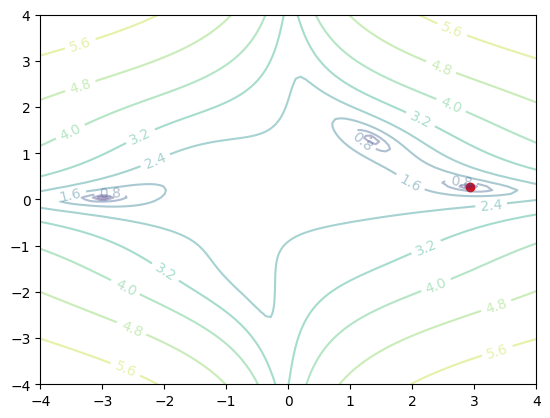

In [57]:
xi = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(xi, xi)
Z = f(X, Y) # Z hat dieselbe Dimension, wie X und Y, also ein Raster Z[0] = erste Komponente, Z[1] = zweite Komponente
norm = np.log(np.hypot(Z[0], Z[1])) # hypot(x,y) = sqrt(x^2 + y^2)
CS = plt.contour(X, Y, norm, levels = 10, alpha = 0.4) # Niveaulinien. alpha: Transparenz
plt.clabel(CS, inline=1, fontsize=10) # labels für die Linien
plt.scatter(*x, color = "r") # die gefundene Nullstelle

Um die Zwischenschritte der Operation plotten zu können, definieren wir die newtoniteration als **generator**. 
Das ist etwas python-spezifisch und für die Numerik nicht Matchentscheidend.

Jedenfalls: wir suchen offenbar ein wenig in der Gegend rum, bis die Nullstelle schliesslich gefunden wird.

[2.10942375e-15 4.44089210e-16]


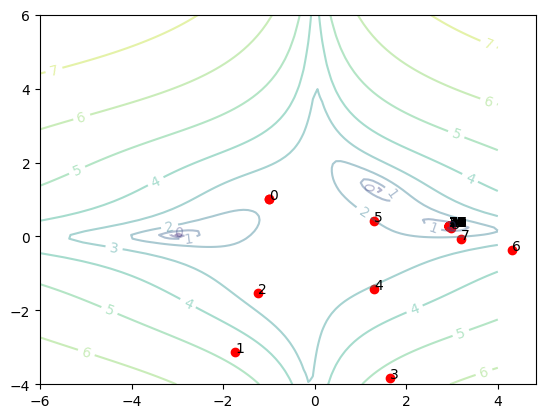

In [58]:
# Newtoniteration, f = Funktion, deren Nullstelle gesucht ist, df = Jacobimatrix, x = Startwert der Iteration
def newtonItr(f, df, x, maxit = 50, tol = 1e-12):
    it = 0 # Iterationszähler
    while it < maxit: 
        delta = np.linalg.solve(df(*x), f(*x))
        yield x
        x -= delta
        it += 1

x = [-1, 1]
xi = np.linspace(x[0]-5, x[0]+5, 100)
yi = np.linspace(x[1]-5, x[1]+5, 100)
X, Y = np.meshgrid(xi, yi)
Z = f(X, Y)
norm = np.log(np.hypot(Z[0], Z[1]))

CS = plt.contour(X, Y, norm, levels = 10, alpha = 0.4) # Niveaulinien. alpha: Transparenz
plt.clabel(CS, inline=1, fontsize=10) # labels für die Linien
plt.scatter(*x, color = "r") # die gefundene Nullstelle

itr = newtonItr(f, df, x)
k = 0
for x in itr:
    plt.scatter(*x, color = "r")
    plt.text(*x, "{:d}".format(k))
    k += 1

print(f(*x))

## Beispiel: GPS
Es soll die Position $(x, y, z)$ eines Punktes auf einer Kugel mit Radius $R = 6370$ Km bestimmt werden, wenn die Abstände des Punktes zu weiteren (bekannten) $(x_i, y_i, z_i)$ bekannt sind. Dies entspricht etwas vereinfacht dem Problem, die Positon eines Punktes auf der Erde zu bestimmen, wenn die Abstände zu mehreren GPS-Satelliten bekannt sind. Unter dieser Annahme muss das nichtlineare Gleichungssystem



Die Positionen $(x_i, y_i, z_i)$ der Satelliten sind bekannt. Zur Bestimmung der Abstände $r_i$ wird die Signallaufzeit zwischen Sendezeit $t_i$ am Satelliten $i$ und Empfangszeit $t$ verwendet:

$$
    r_i^2 = c^2 (t - t_i)^2 
$$

**Problem**: die Uhren zwischen Satellit und Empfänger sind schwer zu synchronisieren. **Trick**: Die Empfangszeit $t$ wird als weiterer, zu bestimmender Parameter betrachtet. Das ergibt eine Unbekannte mehr und die Gleichungen

$$
    f_i(x, y, z, t) := -c^2 (t - t_i)^2 + (x - x_i)^2 + (y - y_i)^2 + (z - z_i)^2 \stackrel!= 0 
$$

Dies ist ein nichtlineares Gleichungssystem für 

$$
    \vec{x} = (t, x, y, z)
$$

Die Zeit $t$ wird nachher nicht mehr benötigt. Das Gleichungssystem hat vier Unbekannte, folglich müssen vier Satelliten sichtbar sein. Wenn mehr als vier Satelliten gleichzeitig sichtbar sind, kann das zur Fehlerkorrektur verwendet werden. Das Gleichungssystem wird damit zu einem **nichtlinearen Ausgleichsproblem**. Wir nehmen hier jedoch an, dass genau vier Satelliten sichtbar sind und dass die Positionen $x_i, y_i, z_i$ der Satelliten perfekt bekannt, und die Sendezeiten $t_i$ der Signale ebenso perfekt synchronisiert sind. 

Für die Berechnung brauchen wir noch die Jacobimatrix von $\vec{f}$:

$$
    \frac{\partial f}{\partial t} = - 2 c^2 (t - t_i) \qquad
    \frac{\partial f}{\partial x} = 2 (x - x_i)       \qquad
    \frac{\partial f}{\partial y} = 2 (y - y_i)       \qquad
    \frac{\partial f}{\partial z} = 2 (z - z_i)       \qquad
$$


#### Erzeugung von Testdaten 
Wir platzieren einen Punkt $(x, y, z)$. Dies ist die Position, die per GPS identifiziert werden soll. Weiter eine Anzahl $N$ von Satelliten an den (bekannten) Stellen $(x_i, y_i)$. Dazu gehören die ebenfalls bekannten Sendezeiten $t_i$ der Satellitensignale.

In [59]:
import numpy as np
import matplotlib.pyplot as plt 

# Testdaten erzeugen
rE = 6370000 # Erdradius [m]
rS = 22000000 # Radius Umlaufbahn der GPS-Satelliten [m]
c  = 299792458 # Lichtgeschwindigkeit [m/s]

def polar2cartesian(phi, theta, r = rE):
    x = r * np.cos(phi) * np.sin(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(theta)
    return x, y, z

def cartesian2polar(x, y, z):
    r = np.linalg.norm( np.array([x, y, z]) )
    
    theta = np.pi/2 - np.arccos(z / r)
    phi = np.arctan2(y, x)
    
    return theta, phi, r

def plotSphere(r = rE):
    angle = np.linspace(0, np.pi, 50)
    Phi, Theta = np.meshgrid(2 * angle, angle)
    X, Y, Z = polar2cartesian(Phi, Theta, r)
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
    plt.axis("off");
    return fig, ax

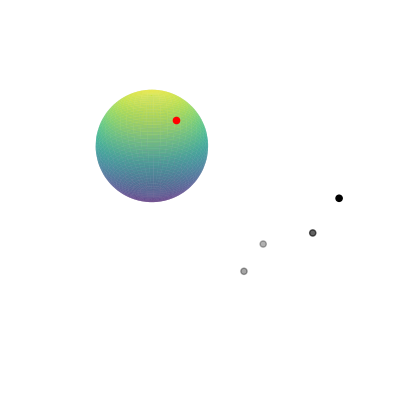

In [60]:
# Position, die gefunden werden soll
phi, theta = 8.72864 * np.pi / 180, np.pi/2 - 47.497743 * np.pi / 180
r = rE + 435
x, y, z = polar2cartesian(phi, theta, r)

# Messdaten xi, yi, ti erzeugen, mit der Option, kleine Fehler einzubauen
def genSatPos(n = 4, err = 0):
    
    phi   = 8.72864 * np.pi / 180 + 2 * np.random.rand(4)
    theta = np.pi/2 - 47.497743 * np.pi / 180 + 2 * np.random.rand(4)
    xi, yi, zi = polar2cartesian(phi, theta, rS)
    ti = -np.sqrt((xi - x)**2 + (yi - y)**2 + (zi - z)**2) / c

    # Ungenauigkeiten in die Positionen einbauen. Die Signallaufzeiten passen damit nicht mehr genau zu den Positionen
    xi += err * np.random.randn(n) 
    yi += err * np.random.randn(n)
    zi += err * np.random.randn(n)
    
    return xi, yi, zi, ti

xi, yi, zi, ti = genSatPos()

fig, ax = plotSphere()
ax.view_init(elev=30, azim=-25, roll=0)

ax.scatter(x*1.2, y*1.2, z*1.2, color = "red")
ax.scatter(xi, yi, zi, color = "k")
ax.set_aspect('equal')

Wir lösen das Gleichungssystem mit dem Newtonverfahren. Die Aufgabe ist (im Gegensatz zum obigen Beispiel) numerisch eher gutmütig und wir können als Startwert einfach $\vec{0}$ verwenden. 

In [4]:

def gps(ti, xi, yi, zi, p = np.array([0., 0, 0, 0]) ):
    
    # Optimierungsfunktion, abhängig von ti, xi, yi, zi
    f = lambda t, x, y, z: -c**2*(t - ti)**2 + (x - xi)**2 + (y - yi)**2 + (z - zi)**2
    J = lambda t, x, y, z: np.array([- 2 * c**2 * (t - ti), 2 * (x - xi), 2 * (y - yi), 2 * (z - zi)]).T

    delta = 1 # dummy wg. Abbruchbedingung
    it = 0
    while (np.linalg.norm(delta) > 1e-7) and (it < 100):
        delta = np.linalg.solve(J(*p),  f(*p))
        p -= delta
        it += 1
    return p

tGPS, xGPS, yGPS, zGPS = gps(ti, xi, yi, zi)

thetaGPS, phiGPS, rGPS = cartesian2polar(xGPS, yGPS, zGPS)

print("ursprüngliche Koordinaten:  phi = ", 
      phi * 180 / np.pi, ", theta = ", theta * 180 / np.pi, ", h = ", r - rE)
print("rekonstruierte Koordinaten: ", 
      "phi = ", np.round(phiGPS * 180 / np.pi, 5), 
      ", theta = ", np.round(90 - thetaGPS * 180 / np.pi, 5), 
      ", h = ", np.round(rGPS - rE, 5))


ursprüngliche Koordinaten:  phi =  8.72864 , theta =  42.502257 , h =  435
rekonstruierte Koordinaten:  phi =  8.72864 , theta =  42.50226 , h =  435.0
